# Learning Gymnasium

Useful Links:

`https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf`

`https://gymnasium.farama.org/environments/box2d/car_racing/#starting-state`

`https://github.com/higgsfield/RL-Adventure`

`https://docs.cleanrl.dev/rl-algorithms/ppo/`


In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

In [2]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
obs, info = env.reset(seed=42)

print("Observation space:", env.observation_space)
print("Action space:     ", env.action_space)
print()
print("Sample observation:", obs)
print()

action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action taken: {action}")
print(f"Reward:       {reward:.4f}")
print(f"Terminated:   {terminated}  |  Truncated: {truncated}")
print(f"Info:         {info}")

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space:      Discrete(4)

Sample observation: [ 0.00229702  1.4181306   0.23264714  0.32046658 -0.00265488 -0.05269808
  0.          0.        ]

Action taken: 2
Reward:       -2.4970
Terminated:   False  |  Truncated: False
Info:         {}


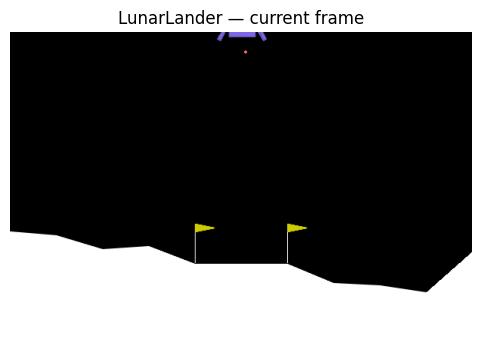

In [3]:
frame = env.render()
plt.figure(figsize=(6, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("LunarLander — current frame")
plt.show()

In [4]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

env = gym.make("LunarLander-v3", render_mode="rgb_array")
obs, info = env.reset(seed=42)

frames = []
terminated, truncated = False, False

while not (terminated or truncated):
    frames.append(env.render())
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

env.close()
print(f"Episode finished after {len(frames)} frames")

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
img = ax.imshow(frames[0])

def update(frame):
    img.set_data(frame)
    return [img]

ani = FuncAnimation(fig, update, frames=frames, interval=30, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())

Episode finished after 101 frames


In [ ]:
# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="rgb_array")

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)
for _ in range(1000):
    # this is where you would insert your policy
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

env.close()